# sklearn Models

This notebook walks through the deckard Python API from a sklearn-centric perspective, then branches into the main optional extensions that fit naturally into that workflow.

## Navigation

1. Environment and imports
2. Core dataset API
3. Core model API
4. Adversarial attack API
5. End-to-end experiment composition
6. Fairness extension
7. ANJANA privacy extension
8. Survival extension
9. Yellowbrick plotter
10. Seaborn plotter

Each runnable section is introduced by a markdown cell so the notebook reads like a guided tour rather than a raw script dump.

## Optional Dependencies

This notebook uses sklearn workflows with Seaborn and Yellowbrick visualization.

Recommended extras:

- `docs`
- `seaborn`
- `yellowbrick`

Install from repository root:

```bash
pip install -e '.[docs,seaborn,yellowbrick]'
```

In [1]:
# Optional dependency installation (run only if your environment is missing packages)
# !pip install -e '../../.[docs,seaborn,yellowbrick]'

## 1. Environment and Imports

This setup cell imports the core deckard classes used throughout the notebook, creates a workspace-local output folder for artifacts, and enables inline plotting. The imports cover the sklearn-oriented core API plus the major extensions and plotter backends.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from deckard.attack import AttackConfig
from deckard.data import DataConfig
from deckard.experiment import ExperimentConfig
from deckard.file import FileConfig
from deckard.model import ModelConfig
from deckard.plugins.anjana.data import AnjanaDataConfig
from deckard.plugins.fairlearn.data import FairlearnDataConfig
from deckard.plugins.fairlearn.model import FairlearnModelConfig
from deckard.plugins.lifelines import LifelinesDataConfig, SurvivalModelConfig
from deckard.plugins.lifelines.experiment import SurvivalExperimentConfig
from deckard.plugins.lifelines.score import DefaultLifelinesConfig
from deckard.plugins.seaborn import SeabornPlotConfig, SeabornPlotConfigList
from deckard.plugins.yellowbrick import YellowbrickPlotConfig
from deckard.plugins.fairlearn.score import DefaultFairlearnScorerConfig
from deckard.score.attack import FairlearnAttackScorerConfig

NOTEBOOK_ROOT = Path(".")
ARTIFACT_DIR = NOTEBOOK_ROOT / "build" / "sklearn"
PLOT_DIR = ARTIFACT_DIR / "plots"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Unique output file paths for each step
data_file = ARTIFACT_DIR / "sklearn_data.csv"
sklearn_model_file = ARTIFACT_DIR / "sklearn_model.pkl"
score_file = ARTIFACT_DIR / "sklearn_scores.csv"
attack_file = ARTIFACT_DIR / "sklearn_attack_results.csv"
plot_file = ARTIFACT_DIR / "sklearn_attack_plot.png"

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (8, 5)

print(f"Notebook root: {NOTEBOOK_ROOT}")
print(f"Artifacts directory: {ARTIFACT_DIR}")

/Users/c.meyers/.pyenv/versions/3.10.20/envs/deckard/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Notebook root: .
Artifacts directory: build/sklearn


## 2. Core Dataset API

deckard starts with a data configuration object. This cell builds a small synthetic classification dataset using sklearn-compatible generation under the hood, materializes the train/test split, and previews the resulting arrays and score metadata.

In [3]:
data = DataConfig(
    dataset_name="make_classification",
    data_params={
        "n_samples": 80,
        "n_features": 10,
        "n_informative": 4,
        "n_redundant": 0,
        "n_clusters_per_class": 1,
        "n_classes": 2,
        "random_state": 17,
    },
    train_size=60,
    test_size=20,
    random_state=42,
    stratify=True,
    classifier=True,
    target="target",
)

dataset_scores = data(files={"score_file": score_file})

print("Train shape:", data.X_train.shape)
print("Test shape:", data.X_test.shape)
print("Train labels:", np.bincount(np.asarray(data.y_train, dtype=int)))
print("Dataset score keys:", sorted(dataset_scores.keys())[:10])

Train shape: (60, 10)
Test shape: (20, 10)
Train labels: [30 30]
Dataset score keys: ['data_load_time', 'data_pipeline_time', 'data_sample_time', 'data_score_time', 'files', 'pipeline_fit_time', 'pipeline_transform_time', 'pipeline_y_fit_time', 'pipeline_y_transform_time', 'test']


### 2b. DataConfig Sampling

deckard supports pluggable samplers through `data.sample` to control how train/test/validation indices are generated.

Built-in sampler classes:
- `SplitSampler`: deterministic 3-way split using `val_size` first, then `test_size` on the remaining pool.
- `KFoldSampler`: disjoint validation folds (`fold` chooses which fold is held out), then train/test split inside the remaining data.
- `ShuffleSampler`: Monte Carlo style repeated random validation splits (`fold` chooses a split index); validation folds are not guaranteed to be disjoint.

Configuration patterns:
- String shorthand: `sampler="split"`
- Explicit object: `sampler=KFoldSampler(n_splits=5, shuffle=True)`
- Hydra-style dict: `sampler={"name": "deckard.data.sample.ShuffleSampler", "n_splits": 4}`

Notes:
- `val_size` is required for `SplitSampler` and `ShuffleSampler`.
- `fold` is used by `KFoldSampler` and `ShuffleSampler` to select one split from the generated set.
- `stratify=True` keeps class proportions stable across splits when possible.

In [4]:
from deckard.data.sample import KFoldSampler, ShuffleSampler, SplitSampler


def build_sampled_data(sample, *, split=0, val_size=0.2):
    cfg = DataConfig(
        dataset_name="make_classification",
        data_params={
            "n_samples": 130,
            "n_features": 8,
            "n_informative": 4,
            "n_redundant": 0,
            "n_clusters_per_class": 1,
            "n_classes": 2,
            "random_state": 13,
        },
        test_size=0.25,
        val_size=val_size,
        split=split,
        random_state=42,
        stratify=True,
        classifier=True,
        target="target",
        sampler=sample,
    )
    cfg()
    return cfg


split_cfg = build_sampled_data(SplitSampler())
kfold_cfg_fold0 = build_sampled_data(KFoldSampler(n_splits=4, shuffle=True), split=0)
kfold_cfg_fold1 = build_sampled_data(KFoldSampler(n_splits=4, shuffle=True), split=1)
shuffle_cfg_fold0 = build_sampled_data(ShuffleSampler(n_splits=4, val_size=0.2), split=0)
shuffle_cfg_fold1 = build_sampled_data(ShuffleSampler(n_splits=4, val_size=0.2), split=1)

summary = pd.DataFrame(
    [
        {
            "sampler": "SplitSampler",
            "fold": "-",
            "train_n": split_cfg.train_n,
            "test_n": split_cfg.test_n,
            "val_n": split_cfg.val_n,
        },
        {
            "sampler": "KFoldSampler",
            "fold": 0,
            "train_n": kfold_cfg_fold0.train_n,
            "test_n": kfold_cfg_fold0.test_n,
            "val_n": kfold_cfg_fold0.val_n,
        },
        {
            "sampler": "KFoldSampler",
            "fold": 1,
            "train_n": kfold_cfg_fold1.train_n,
            "test_n": kfold_cfg_fold1.test_n,
            "val_n": kfold_cfg_fold1.val_n,
        },
        {
            "sampler": "ShuffleSampler",
            "fold": 0,
            "train_n": shuffle_cfg_fold0.train_n,
            "test_n": shuffle_cfg_fold0.test_n,
            "val_n": shuffle_cfg_fold0.val_n,
        },
        {
            "sampler": "ShuffleSampler",
            "fold": 1,
            "train_n": shuffle_cfg_fold1.train_n,
            "test_n": shuffle_cfg_fold1.test_n,
            "val_n": shuffle_cfg_fold1.val_n,
        },
    ]
)

kfold_val_overlap = len(
    set(kfold_cfg_fold0.val_indices).intersection(set(kfold_cfg_fold1.val_indices))
)
shuffle_val_overlap = len(
    set(shuffle_cfg_fold0.val_indices).intersection(set(shuffle_cfg_fold1.val_indices))
)

print("Validation overlap (KFold fold0 vs fold1):", kfold_val_overlap)
print("Validation overlap (Shuffle fold0 vs fold1):", shuffle_val_overlap)

summary

Validation overlap (KFold fold0 vs fold1): 33
Validation overlap (Shuffle fold0 vs fold1): 26


,sampler,fold,train_n,test_n,val_n
0,SplitSampler,-,104,26,NaN
1,KFoldSampler,0,77,20,33.0
2,KFoldSampler,1,77,20,33.0
3,ShuffleSampler,0,83,21,26.0
4,ShuffleSampler,1,83,21,26.0


## 3. Core Model API

A `ModelConfig` wraps a sklearn estimator and standardizes training, prediction, persistence, and scoring. This example fits logistic regression on the dataset above and inspects the resulting score dictionary and predictions.

In [5]:
model = ModelConfig(
    model_type="sklearn.linear_model.LogisticRegression",
    classifier=True,
    model_params={"max_iter": 100},
)

model_scores = model(data, files={"score_file": score_file})

print("Model score keys:", sorted(model_scores.keys())[:12])
print("Accuracy:", model_scores.get("accuracy"))
print("Prediction shape:", model.predictions.shape)
print("Training prediction shape:", model.training_predictions.shape)

Model score keys: ['accuracy', 'data_load_time', 'data_pipeline_time', 'data_sample_time', 'data_score_time', 'f1', 'files', 'files.data_file', 'files.score_file', 'log_loss', 'pipeline_fit_time', 'pipeline_transform_time']
Accuracy: 0.75
Prediction shape: (20,)
Training prediction shape: (60,)


## 4. Adversarial Attack API

`AttackConfig` lets you run ART-backed attacks against a trained model with consistent scoring and naming. This example uses Fast Gradient Method against the sklearn classifier and prints the evasion-related metrics that come back.

In [6]:
attack = AttackConfig(
    attack_type="art.attacks.evasion.FastGradientMethod",
    attack_params={"eps": 0.1},
    attack_size=10,
    alias="fgm",
)

attack_scores = attack(data=data, model=model)

evasion_keys = [key for key in sorted(attack_scores) if key.startswith("evasion_")]
print("Evasion metric keys:", evasion_keys)
print("Attack size:", attack_scores.get("attack_size"))
print("Attack prediction shape:", np.asarray(attack.attack_predictions).shape)

Evasion metric keys: ['evasion_accuracy', 'evasion_f1-score', 'evasion_precision', 'evasion_recall', 'evasion_success']
Attack size: 10
Attack prediction shape: (10, 2)


## 5. End-to-End Experiment Composition

`ExperimentConfig` composes the data, model, optional attack, optional detector, and optional file outputs into a single orchestrated run. This is the clearest way to express a reproducible sklearn workflow in deckard.

In [7]:
experiment_files = FileConfig(
    data_file=(ARTIFACT_DIR / "experiment_data_lr.pkl").as_posix(),
    model_file=(ARTIFACT_DIR / "experiment_model_lr.pkl").as_posix(),
    score_file=(ARTIFACT_DIR / "experiment_scores_lr.json").as_posix(),
)

experiment = ExperimentConfig(
    data=DataConfig(
        dataset_name="make_classification",
        data_params={
            "n_samples": 300,
            "n_features": 12,
            "n_informative": 5,
            "n_redundant": 0,
            "n_clusters_per_class": 1,
            "n_classes": 2,
            "random_state": 11,
        },
        train_size=0.5,
        test_size=0.25,
        val_size=0.25,
        random_state=42,
        stratify=True,
        classifier=True,
        target="target",
        # Explicit 3-way sampler so X_val/y_val are available for score_mode='val'.
        sampler="split",
    ),
    model=ModelConfig(
        model_type="sklearn.linear_model.LogisticRegression",
        classifier=True,
        model_params={"max_iter": 100},
    ),
    attack=AttackConfig(
        attack_type="art.attacks.evasion.FastGradientMethod",
        attack_params={"eps": 0.05},
        attack_size=50,
        alias="fgm",
    ),
    # detector=detector,
    files=experiment_files,
    score_mode="val",
)

experiment_scores = experiment()

interesting_keys = [
    key
    for key in sorted(experiment_scores)
    if "evasion" in key or key.startswith("validation_")
]

print("Interesting experiment keys:", interesting_keys)
print({key: experiment_scores[key] for key in interesting_keys[:8]})

Interesting experiment keys: ['evasion_accuracy', 'evasion_f1-score', 'evasion_precision', 'evasion_recall', 'evasion_success', 'validation_n', 'validation_prediction_time', 'validation_score_time']
{'evasion_accuracy': 0.88, 'evasion_f1-score': 0.88, 'evasion_precision': 0.88, 'evasion_recall': 0.88, 'evasion_success': 0.06, 'validation_n': 75, 'validation_prediction_time': 0.0004670000000004393, 'validation_score_time': 0.004347000000000101}


## 6. Fairness Extension

The fairness extension augments the sklearn flow with sensitive-feature-aware data handling, fairness-aware model behavior, and group-level attack scoring via Fairlearn `MetricFrame`. This section keeps the example intentionally small so the API shape is easy to see.

In [8]:
fair_data = FairlearnDataConfig(
    dataset_name="make_classification",
    data_params={
        "n_samples": 60,
        "n_features": 10,
        "n_informative": 4,
        "n_redundant": 0,
        "n_clusters_per_class": 1,
        "n_classes": 2,
        "random_state": 23,
    },
    train_size=45,
    test_size=15,
    random_state=42,
    stratify=True,
    classifier=True,
    sensitive_columns=["feature_0"],
)
fair_data()

# Debug: Check sensitive feature extraction and alignment
print(
    "Sensitive train exists:",
    hasattr(fair_data, "_sensitive_train"),
    "Length:",
    len(getattr(fair_data, "_sensitive_train", [])),
)
print(
    "Sensitive test exists:",
    hasattr(fair_data, "_sensitive_test"),
    "Length:",
    len(getattr(fair_data, "_sensitive_test", [])),
)
print("y_train length:", len(fair_data.y_train))
print("y_test length:", len(fair_data.y_test))

fair_model = FairlearnModelConfig(
    model_type="sklearn.linear_model.LogisticRegression",
    classifier=True,
    model_params={"max_iter": 50},
    data=fair_data,
)

fair_model_scores = fair_model(fair_data)

print("Fairness data score keys:", sorted(fair_data.score_dict.keys())[:10])
fairness_model_keys = [
    key for key in sorted(fair_model_scores) if "accuracy" in key or "fair" in key
]
print("Fairness model keys:", fairness_model_keys[:12])

fair_attack_scorer = FairlearnAttackScorerConfig()
group_scores = fair_attack_scorer.score_evasion(
    ben_pred_labels=np.array([0, 1, 0, 1]),
    adv_pred_labels=np.array([0, 1, 1, 1]),
    y_true=np.array([0, 1, 0, 1]),
    attack_size=4,
    sensitive_features=np.array(["A", "A", "B", "B"]),
)

print(group_scores)

Sensitive train exists: True Length: 45
Sensitive test exists: True Length: 15
y_train length: 45
y_test length: 15
Fairness data score keys: ['data_load_time', 'data_pipeline_time', 'data_sample_time', 'data_score_time', 'fairlearn_test_class_count_max', 'fairlearn_test_class_count_min', 'fairlearn_test_class_imbalance_ratio', 'fairlearn_test_mutual_information_max', 'fairlearn_test_mutual_information_mean', 'fairlearn_test_num_classes']
Fairness model keys: ['-0.01985779112159214_accuracy', '-0.38865906763600955_accuracy', '-0.42607796272588305_accuracy', '-0.7729341246718244_accuracy', '-0.9643034188675517_accuracy', '-0.9749733421103569_accuracy', '-1.0380795904801268_accuracy', '-1.73485440811038_accuracy', '-1.7449779997932628_accuracy', '0.37654166387211774_accuracy', '0.8276941810208531_accuracy', '1.529158055900424_accuracy']
{'evasion_test': {'success': 0.25}, 'evasion_accuracy_overall': 0.8, 'evasion_f1_overall': 0.7, 'evasion_A_accuracy': 1.0, 'evasion_A_f1': 1.0, 'evasion_

## 7. ANJANA Privacy Extension

The ANJANA extension adds privacy-oriented dataset handling and privacy metrics such as k-anonymity, l-diversity, and t-closeness. This example builds an `AnjanaDataConfig` on top of synthetic tabular data and inspects the privacy score outputs.

In [9]:
anjana_data = AnjanaDataConfig(
    dataset_name="make_classification",
    data_params={
        "n_samples": 40,
        "n_features": 6,
        "n_informative": 3,
        "n_redundant": 0,
        "n_clusters_per_class": 1,
        "random_state": 0,
    },
    # Use proportions so splits remain valid after ANJANA suppression/generalization.
    train_size=0.7,
    test_size=0.3,
    classifier=True,
    random_state=42,
    target="target",
    quasi_identifiers=["feature_0", "feature_1"],
    sensitive_attribute="target",
    sensitive_columns=["feature_0"],
    anjana_defense={
        "name": "anjana.anonymity.k_anonymity",
        "k": 2,
        "supp_level": 100,
    },
    hierarchy_interval_sizes={"feature_0": [1, 5, 10], "feature_1": [1, 5, 10]},
    scorer=None,
)

anjana_scores = anjana_data()

print("Anjana score keys:", sorted(anjana_scores.keys()))
print("Quasi identifiers:", anjana_data.quasi_identifiers)
print("Sensitive attribute:", anjana_data.sensitive_attribute)
print("Sample sizes:", anjana_data.train_n, anjana_data.test_n)

Anjana score keys: ['data_load_time', 'data_pipeline_time', 'data_sample_time', 'data_score_time', 'files', 'pipeline_fit_time', 'pipeline_transform_time', 'pipeline_y_fit_time', 'pipeline_y_transform_time', 'test_n', 'train_n']
Quasi identifiers: ['feature_0', 'feature_1']
Sensitive attribute: target
Sample sizes: 24 11


## 8. Survival Extension

The survival extension is separate from the standard sklearn classifier/regressor path, but it fits the same config-first style. This section demonstrates survival data preparation, survival model configuration, and a `SurvivalExperimentConfig` run using lifelines-backed components.

In [10]:
survival_data = LifelinesDataConfig(
    dataset_name="rossi",
    duration_col="week",
    event_col="arrest",
    train_size=0.7,
    test_size=0.3,
    random_state=42,
    scorer=DefaultLifelinesConfig(),
)

survival_model = SurvivalModelConfig(
    model_type="lifelines.fitters.coxph_fitter.CoxPHFitter",
    duration_col="week",
    event_col="arrest",
    scorer=DefaultLifelinesConfig(),
)

survival_experiment = SurvivalExperimentConfig(
    data=survival_data,
    model="cox",
    target="arrest",
    event_col="arrest",
    duration_col="week",
    classifier=False,
)

survival_scores = survival_experiment()

print(survival_scores["aft_table"])

INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets?sort=downloads&limit=100 "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets?sort=downloads&limit=100 "HTTP/1.1 200 OK"


INFO:deckard.data.base:Data loaded from lifelines.rossi in 0.00 seconds


INFO:deckard.data.base:Data sampled in 0.00 seconds


INFO:deckard.utils:Data saved to plots/survival/cox_summary.csv


  model    t0         AIC  concordance      ICI      E50
0   cox  0.35  914.581447          0.5  0.00294  0.00294


## 9. Yellowbrick Plotter

The Yellowbrick backend works from an experiment object and generates single-run diagnostic visualizations such as ROC curves, prediction error plots, and feature importance views. This example renders one sklearn classification visual.

INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets?sort=downloads&limit=100 "HTTP/1.1 200 OK"


INFO:httpx:HTTP Request: GET https://huggingface.co/api/datasets?sort=downloads&limit=100 "HTTP/1.1 200 OK"


INFO:deckard.data.base:Data loaded from make_classification in 0.00 seconds


INFO:deckard.data.base:Data loaded in 0.00 seconds


INFO:deckard.data.base:Data sampled in 0.00 seconds


...

INFO:deckard.experiment.base:No attack config provided, skipping attack.


INFO:deckard.experiment.base:No detector config provided, skipping detector phase.


INFO:deckard.experiment.base:No score_file specified, skipping score saving.


INFO:deckard.plugins.yellowbrick.plot:Yellowbrick classifier plot saved to build/sklearn/plots/yellowbrick_roc_auc.png


Yellowbrick plot written: build/sklearn/plots/yellowbrick_roc_auc.png


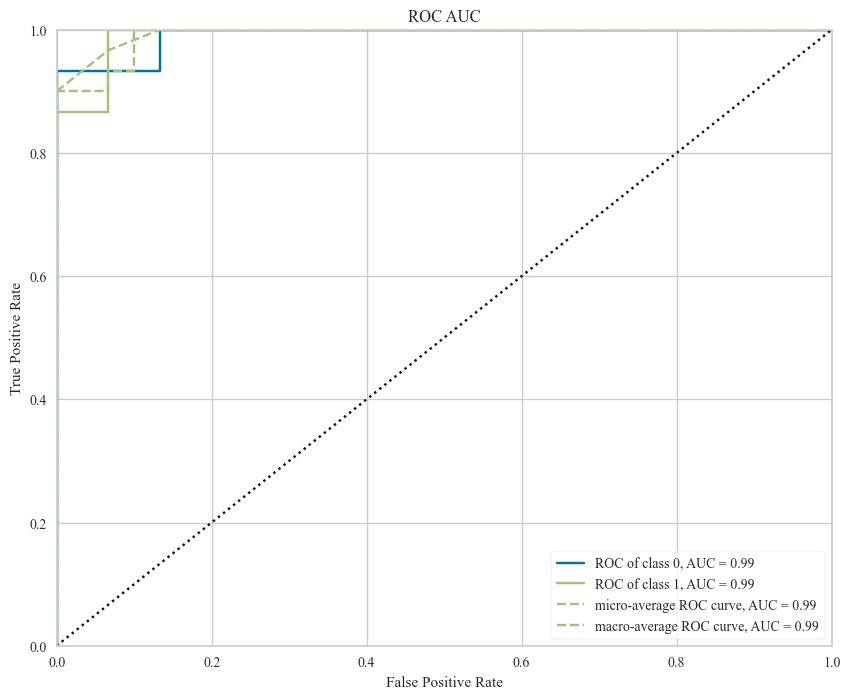

In [11]:
yellowbrick_experiment = ExperimentConfig(
    data=DataConfig(
        dataset_name="make_classification",
        data_params={
            "n_samples": 120,
            "n_features": 20,
            "n_classes": 2,
            "random_state": 3,
        },
        train_size=90,
        test_size=30,
        classifier=True,
        stratify=True,
    ),
    model=ModelConfig(
        model_type="sklearn.linear_model.LogisticRegression",
        classifier=True,
        model_params={"max_iter": 100},
    ),
    files=FileConfig(data_file="", model_file=""),
)

yellowbrick_experiment()

yellowbrick_path = (PLOT_DIR / "yellowbrick_roc_auc.png").as_posix()
yellowbrick_plot = YellowbrickPlotConfig(
    experiment=yellowbrick_experiment,
    plot_type="roc_auc",
    features="all",
    classes="all",
    title="ROC AUC",
    save_path=yellowbrick_path,
)

yellowbrick_plot()
print("Yellowbrick plot written:", yellowbrick_path)

## 10. Seaborn Plotter

The Seaborn backend is designed for tabular result aggregation. Here we build a small results table in-memory, write it to disk, and render both a single plot and a small plot list so the multi-plot API is visible.

INFO:deckard.utils:Data loaded from build/sklearn/seaborn_results.csv


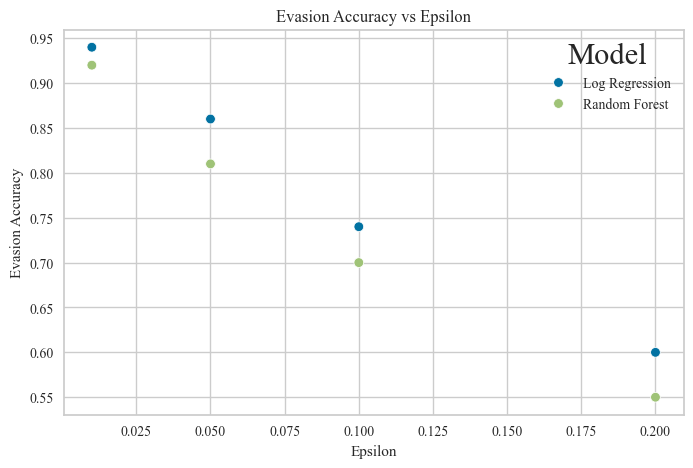

INFO:deckard.utils:Data loaded from build/sklearn/seaborn_results.csv


Seaborn plots written: build/sklearn/plots/seaborn_scatter.png build/sklearn/plots/seaborn_line.png


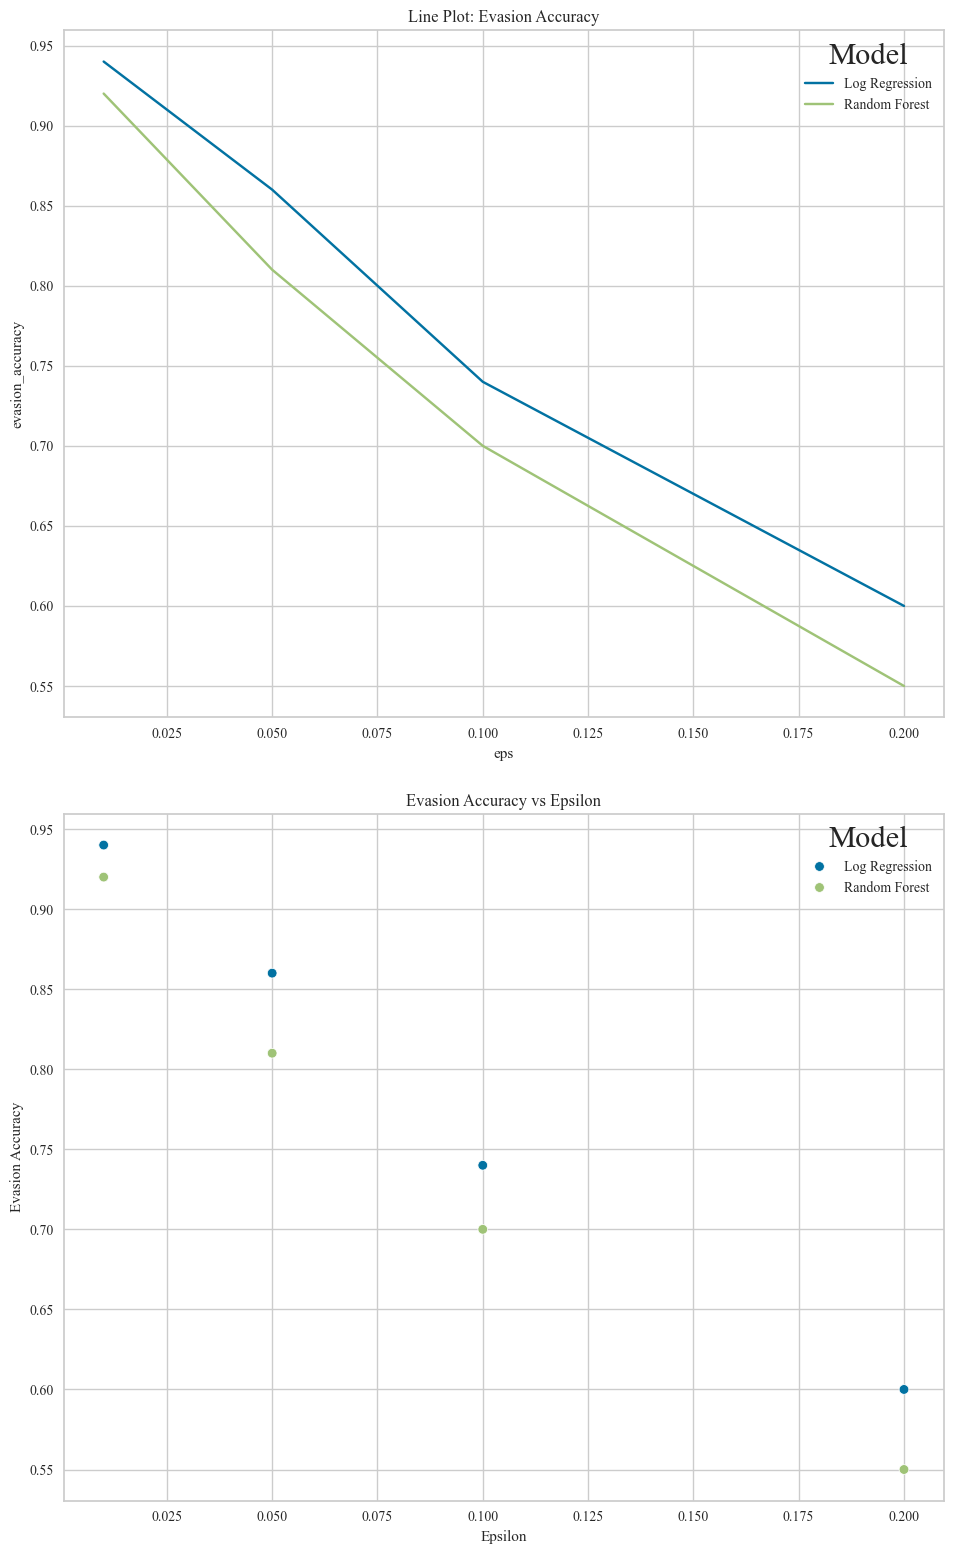

In [12]:
results_df = pd.DataFrame(  # Example results dataframe
    {
        "eps": [0.01, 0.05, 0.10, 0.20, 0.01, 0.05, 0.10, 0.20],
        "evasion_accuracy": [0.94, 0.86, 0.74, 0.60, 0.92, 0.81, 0.70, 0.55],
        "accuracy": [0.96, 0.96, 0.96, 0.96, 0.93, 0.93, 0.93, 0.93],
        "model": ["Log Regression"] * 4 + ["Random Forest"] * 4,
    }
)

results_csv = ARTIFACT_DIR / "seaborn_results.csv"
results_df.to_csv(results_csv, index=False)

scatter_path = (PLOT_DIR / "seaborn_scatter.png").as_posix()
line_path = (PLOT_DIR / "seaborn_line.png").as_posix()

seaborn_scatter = SeabornPlotConfig(
    plot_type="scatter",
    data_file=results_csv.as_posix(),
    x="eps",
    y="evasion_accuracy",
    hue="model",
    title="Evasion Accuracy vs Epsilon",
    xlabel="Epsilon",
    ylabel="Evasion Accuracy",
    legend_title="Model",
    plot_file=scatter_path,
)

ax = seaborn_scatter()
plt.show()

plot_list = SeabornPlotConfigList(
    data_file=results_csv.as_posix(),
    plots=[
        SeabornPlotConfig(
            plot_type="line",
            data_file=results_csv.as_posix(),
            x="eps",
            y="evasion_accuracy",
            hue="model",
            title="Line Plot: Evasion Accuracy",
            plot_file=line_path,
            legend_title="Model",
        ),
        seaborn_scatter,
    ],
)

plot_list()
print("Seaborn plots written:", scatter_path, line_path)